<a href="https://colab.research.google.com/github/gianayee06/GitHub-Workshop/blob/main/Assignments/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1



## Question 1:
{method, implementation, answer}

Examine the value of sparse matricies by comparing the approximate computational efficiencies of sparse and dense solvers (on the same system). Use the %timeit function to approximate the complexity.

HINT: Refer to the lecture notes on how to generate, store, and apply sparse solvers.  

In [30]:
#imports library in python that can compute with arrays and matrices
import numpy as np

#sets the size of equations and unknowns
n = 5
#This creates a 5x5 grid with all entries being 0
A = np.zeros((n,n))

#Fills main diagonal across the matrix with 2
np.fill_diagonal(A,2)

#Starting at row one, fill the main diagonal with -1
np.fill_diagonal(A[1:],-1)

#Starting at row 1, column 1, file the main diagonal with -1
np.fill_diagonal(A[:,1:],-1)

print(A)

[[ 2. -1.  0.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  2.]]


In [31]:

#Setting each equation within the system to equal 1
b = np.ones(n)

print(b)

[1. 1. 1. 1. 1.]


In [32]:
#imports a csr_matrix from Scipy's module (Compressed Sparse Row)
from scipy.sparse import csr_matrix

#Saves all non zero entries with coordinates attached to those values
A_sparse = csr_matrix(A)

print(A_sparse)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13 stored elements and shape (5, 5)>
  Coords	Values
  (0, 0)	2.0
  (0, 1)	-1.0
  (1, 0)	-1.0
  (1, 1)	2.0
  (1, 2)	-1.0
  (2, 1)	-1.0
  (2, 2)	2.0
  (2, 3)	-1.0
  (3, 2)	-1.0
  (3, 3)	2.0
  (3, 4)	-1.0
  (4, 3)	-1.0
  (4, 4)	2.0


In [6]:
#imports sparse solver from scipy
from scipy.sparse.linalg import spsolve

#This uses a dense solver to solve our matrix
x_dense = np.linalg.solve(A,b)

#this uses a sparse solver to solve our matrix
x_sparse = spsolve(A_sparse,b)

print(x_dense)
print(x_sparse)

[2.5 4.  4.5 4.  2.5]
[2.5 4.  4.5 4.  2.5]


In [8]:
#This measures the time the dense solver took
%timeit np.linalg.solve(A,b)
#This measures the time the sparse solver took
%timeit spsolve(A_sparse,b)

6.58 µs ± 1.37 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)
26.4 µs ± 769 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [21]:
n = 200
A = np.zeros((n,n))

np.fill_diagonal(A,2)
np.fill_diagonal(A[1:],-1)
np.fill_diagonal(A[:,1:],-1)

b = np.ones(n)

A_sparse = csr_matrix(A)

x_dense = np.linalg.solve(A,b)
x_sparse = spsolve(A_sparse,b)

two_dense = %timeit -o np.linalg.solve(A,b)
two_sparse = %timeit -o spsolve(A_sparse,b)


272 µs ± 4.02 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
84.4 µs ± 12 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [26]:
n = 800
A = np.zeros((n,n))

np.fill_diagonal(A,2)
np.fill_diagonal(A[1:],-1)
np.fill_diagonal(A[:,1:],-1)

b = np.ones(n)

A_sparse = csr_matrix(A)

x_dense = np.linalg.solve(A,b)
x_sparse = spsolve(A_sparse,b)

eight_dense = %timeit -o np.linalg.solve(A,b)
eight_sparse = %timeit -o spsolve(A_sparse,b)

11.1 ms ± 927 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
237 µs ± 3.02 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [27]:
p_dense = np.log(eight_dense.average/two_dense.average)/np.log(800/200)
p_sparse = np.log(eight_sparse.average/two_sparse.average)/np.log(800/200)

print(p_dense)
print(p_sparse)

2.674863684221044
0.7447659657850169


Dense storage keeps every matrix entry, including zeros, while sparse storage keeps nonzero enteries and information about their positions. I used %timeit to compare dense and sparse solvers on the same equations at different sizes. The dense solver was faster for the smallest case, but the sparse solver became faster as the matrices grew because it could take advantage of the many zeros.

## Question 2

Consider the truss:

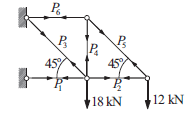


### 2a) Write the linear system for the tensions $P_i$ as equations and in matrix form
{answer}

In [3]:
import numpy as np

s = np.sin(np.pi/4)
c = np.cos(np.pi/4)

A = np.array([
    [-1, 1, -c, 0, 0, 0], #A, x
    [0, 0, s, 1, 0, 0], #A, y
    [0, -1, 0, 0, -c, 0], #B, x
    [0, 0, 0, 0, s, 0], #B, y
    [0, 0, 0, 0, s, -1], #C, x
    [0, 0, 0, -1, -c, 0], #C, y
])

b = np.array([0, 18, 0, 12, 0, 0])

x = np.linalg.solve(A,b)
print(x)


[-42.         -12.          42.42640687 -12.          16.97056275
  12.        ]


Solved for equations by hand and then after figuring them out, created a matrix to solve for the system of equations.

### 2b) Solve for $P_i$ using LU decomposition and substitution.
{method, answer}

In [4]:
from scipy.linalg import lu_factor, lu_solve

# Factor A into its LU form (this is the expensive step, done once)
LU, piv = lu_factor(A)

# Solve using the factors: forward substitution with L, then back substitution with U
P = lu_solve((LU, piv), b)

print(P)

[-42.         -12.          42.42640687 -12.          16.97056275
  12.        ]


### 2c)  Double the loads (18 kN and 12 kN) and solve for $P_i$ again *without refactoring*.
{answer}

In [5]:
# New loads: 36 kN and 24 kN (double the originals)
b2 = np.array([0, 36, 0, 24, 0, 0])

# Reuse the SAME factors from 2b
P2 = lu_solve((LU, piv), b2)

print(P2)

[-84.         -24.          84.85281374 -24.          33.9411255
  24.        ]


## Question 3

Consider the matrix:

$$ A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$$

## 3a) Calculate the condition number of A
{answer}

In [6]:
A3 = np.array([
    [1, 2],
    [3, 4]
])

print(np.linalg.cond(A3))

14.933034373659268


## 3b) Let's use a preconditioner matrix $P$ to improve the condition number of the product $P^{-1} A$. Give 2 examples of $P$ that improve the condition number.

Can you identify the 'perfect' preconditioner? (Consider the easiest matrix to solve!)
{answer, answer}

In [10]:
#Example 1
P1 = np.array([
    [1, 0],
    [0, 4]
])

#NOTE: For both examples, the matrix P1 and P2 must be inversible
# and in order to determine this, their determinant must be
# a non-zero value

#This operation finds a matrix that, when multiplied
# on the left by P1, given us A3
# That result is P^-1 * A
B1 = np.linalg.solve(P1, A3)

print(np.linalg.cond(B1))

13.048362028288917


In [11]:
P2 = np.array([
    [1, 0],
    [3, 4]
])

B2 = np.linalg.solve(P2, A3)

print(np.linalg.cond(B2))

10.403882032022077


In [12]:
# A matrix multiplied by its own inverse gives an identity matrix
# with a condition of 1, the best possible value

P_perfect = A3
B_perfect = np.linalg.solve(P_perfect, A3)

print(np.linalg.cond(B_perfect))

1.0


Both matrices we chose worked: P1 lowered the condition number from 14.933 to 13.048, and P2 lowered it to 10.404. Choosing P to be the same as A gives the best possible condition number, which is 1.